In [1]:
!unzip "archive (2).zip"

Archive:  archive (2).zip
  inflating: Mall_Customers.csv      


In [2]:
# Importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the dataset
df = pd.read_csv('Mall_Customers.csv')

# Displaying the first 5 rows and checking data info
display(df.head())
print("\n--- Data Information ---")
df.info()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40



--- Data Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [3]:
# 1. Descriptive Statistics
print("--- Descriptive Statistics ---")
display(df.describe())

# 2. Feature Selection: We choose 'Annual Income' and 'Spending Score' for clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# 3. Data Normalization/Standardization (Very important for K-Means)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\n✅ Features selected and standardized successfully!")

--- Descriptive Statistics ---


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000



✅ Features selected and standardized successfully!


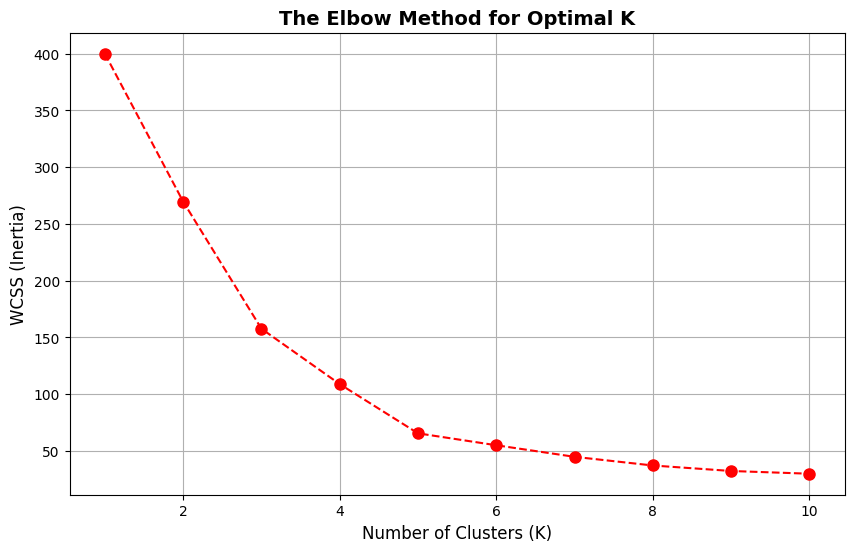

In [4]:
# 4. Finding the optimal number of clusters using the Elbow Method
from sklearn.cluster import KMeans

wcss = [] # Within-Cluster Sum of Square

# Testing 1 to 10 clusters
for i in range(1, 11):
    # n_init=10 is added to avoid warnings in newer versions of scikit-learn
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow Graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='red', markersize=8)
plt.title('The Elbow Method for Optimal K', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('WCSS (Inertia)', fontsize=12)
plt.grid(True)
plt.show()

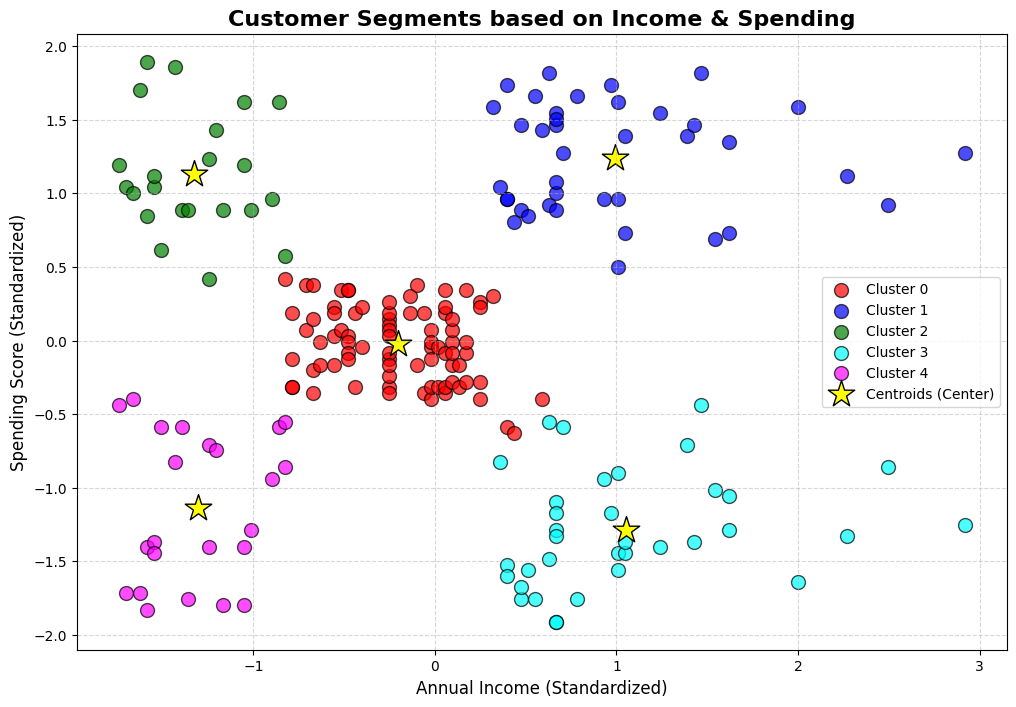

In [5]:
# 5. Training the K-Means model with optimal K=5
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)

# Predicting the cluster label (0 to 4) for each customer
y_kmeans = kmeans.fit_predict(X_scaled)

# Saving the cluster results back into our original dataframe
df['Cluster'] = y_kmeans

# 6. Visualizing all 5 Customer Segments
plt.figure(figsize=(12, 8))

# We will use 5 different colors for 5 clusters
colors = ['red', 'blue', 'green', 'cyan', 'magenta']
cluster_names = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4']

for i in range(5):
    # Plotting points for each cluster
    plt.scatter(X_scaled[y_kmeans == i, 0], X_scaled[y_kmeans == i, 1],
                s=100, c=colors[i], label=cluster_names[i], edgecolors='black', alpha=0.7)

# Plotting the Centroids (The exact center of each group)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=400, c='yellow', label='Centroids (Center)', marker='*', edgecolors='black')

plt.title('Customer Segments based on Income & Spending', fontsize=16, fontweight='bold')
plt.xlabel('Annual Income (Standardized)', fontsize=12)
plt.ylabel('Spending Score (Standardized)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

--- Average Income and Spending per Cluster ---


,Annual Income (Real),Spending Score (Real)
Cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


/tmp/ipykernel_605/1192647009.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Cluster', data=df, palette='Set2')


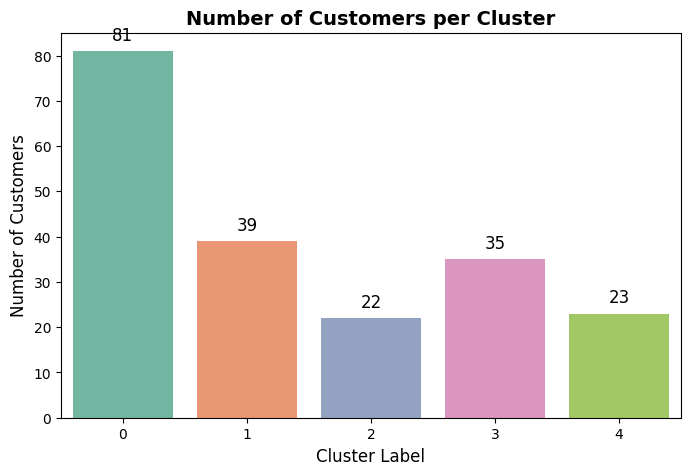

In [6]:
# 7. Profiling each cluster (Calculating average values)
# Using original real values for better understanding
df['Annual Income (Real)'] = X['Annual Income (k$)']
df['Spending Score (Real)'] = X['Spending Score (1-100)']

cluster_profile = df.groupby('Cluster')[['Annual Income (Real)', 'Spending Score (Real)']].mean()
print("--- Average Income and Spending per Cluster ---")
display(cluster_profile)

# 8. Bar Chart: Number of customers per cluster
plt.figure(figsize=(8, 5))
sns.countplot(x='Cluster', data=df, palette='Set2')
plt.title('Number of Customers per Cluster', fontsize=14, fontweight='bold')
plt.xlabel('Cluster Label', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

# Adding exact numbers on top of bars
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

### **Conclusion & Business Recommendations**
Based on the K-Means Clustering analysis, we have successfully segmented the customers into 5 distinct groups. Here are the actionable business recommendations:

1. **Target the Premium VIPs (High Income, High Spending):** This segment is the most profitable. The mall should offer them exclusive premium memberships, early access to new launches, and personalized services to maintain their loyalty.
2. **Engage the 'Savers' (High Income, Low Spending):** These customers have the money but aren't spending it. We should attract them by offering high-quality, value-for-money products, targeted discounts, and engaging ad campaigns.
3. **Volume Drivers (Average Income, Average Spending - The Largest Group):** Since this is our biggest customer base (Cluster 0 with 81 customers), standard promotional offers, loyalty points on daily purchases, and festive sales will keep them engaged and increase overall footfall.